# Task 3: Predictive Modeling — Medal vs No Medal Classification

# Task 3: Predictive Modeling

## Objective
Build binary classification models to predict whether an athlete wins any medal.

## Modeling Strategy
- Handle class imbalance using class weights
- Use 80/20 stratified train-test split
- Train two models:
  - Logistic Regression
  - Random Forest
- Evaluate with Accuracy, Precision, Recall, F1-score, and ROC-AUC
- Interpret feature importance and model behavior

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
#Loading the cleaned dataset
df = pd.read_csv("milan_cortina_2026_cleaned.csv")
df.head()

,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal,Reaction_Time_Missing,WorldCupPoints_Missing,Medal_Won,Experience_Index,VO2_BodyFat_Ratio,GDP_Tradition_Score
0,MC26_1001,Ben Ogden,USA,M,26.0,Cross-Country,1,35.6,1687.0,8.9,91.5,190.0,1,356.0,80000,0.82,Silver,1,0,1,35.6,10.280899,65600.0
1,MC26_1002,Loic Meillard,SUI,M,30.0,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208.0,1,977.0,93000,0.93,Gold,0,0,1,68.7,5.136691,86490.0
2,MC26_1003,Francesca Lollobrigida,ITA,F,35.0,Speed Skating,1,29.0,394.0,10.1,82.6,189.0,3,416.0,38000,0.82,Gold,0,0,1,29.0,8.178218,31160.0
3,MC26_1004,Maria Nilsson,FRA,F,43.0,Ski Jumping,4,26.2,1239.0,9.1,59.3,183.0,2,801.0,48000,0.87,NaN,0,0,0,104.8,6.516484,41760.0
4,MC26_1005,Nils Lewis,GER,M,20.0,Short Track,0,20.2,67.0,12.3,63.1,187.0,2,393.0,52000,0.88,NaN,0,0,0,0.0,5.130081,45760.0


In [3]:
# Check targeted value
df["Medal"].value_counts()

Medal
Gold      49
Silver    32
Bronze    23
Name: count, dtype: int64

In [4]:
# Creating Binary Target
df["Medal_Won"] = np.where(df["Medal"] == "None", 0, 1)

df["Medal_Won"].value_counts(normalize=True) * 100

Medal_Won
1    100.0
Name: proportion, dtype: float64

In [5]:
df.shape
df["Medal"].value_counts()
df["Medal_Won"].value_counts(normalize=True) * 100

Medal_Won
1    100.0
Name: proportion, dtype: float64

In [6]:
df["Medal"].value_counts(dropna=False)

Medal
NaN       283
Gold       49
Silver     32
Bronze     23
Name: count, dtype: int64

In [7]:
# Create binary target correctly
df["Medal_Won"] = np.where(df["Medal"].isna(), 0, 1)

# Check balance
df["Medal_Won"].value_counts()
df["Medal_Won"].value_counts(normalize=True) * 100

Medal_Won
0    73.126615
1    26.873385
Name: proportion, dtype: float64

# Build Modeling Dataset : Data Preparation and Train-Test Split

In [9]:
# ==========================================
# Feature Selection
# ==========================================

target = "Medal_Won"

drop_cols = [
    "Athlete_ID",
    "Athlete_Name",
    "Medal",
    "Medal_Won"
]

X = df.drop(columns=drop_cols)
y = df[target]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X.head()

X Shape: (387, 19)
y Shape: (387,)


,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Reaction_Time_Missing,WorldCupPoints_Missing,Experience_Index,VO2_BodyFat_Ratio,GDP_Tradition_Score
0,USA,M,26.0,Cross-Country,1,35.6,1687.0,8.9,91.5,190.0,1,356.0,80000,0.82,1,0,35.6,10.280899,65600.0
1,SUI,M,30.0,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208.0,1,977.0,93000,0.93,0,0,68.7,5.136691,86490.0
2,ITA,F,35.0,Speed Skating,1,29.0,394.0,10.1,82.6,189.0,3,416.0,38000,0.82,0,0,29.0,8.178218,31160.0
3,FRA,F,43.0,Ski Jumping,4,26.2,1239.0,9.1,59.3,183.0,2,801.0,48000,0.87,0,0,104.8,6.516484,41760.0
4,GER,M,20.0,Short Track,0,20.2,67.0,12.3,63.1,187.0,2,393.0,52000,0.88,0,0,0.0,5.130081,45760.0


In [10]:
# Identify Numeric / Categorical Columns

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumeric Columns:")
print(numeric_cols)

Categorical Columns:
['Country', 'Gender', 'Sport']

Numeric Columns:
['Age', 'Previous_Olympics', 'Training_Hours_Per_Week', 'Altitude_Training_m', 'Body_Fat_Pct', 'VO2max', 'Reaction_Time_ms', 'Career_Injuries', 'World_Cup_Points_Preseason', 'Country_GDP_per_capita', 'Winter_Sport_Tradition_Index', 'Reaction_Time_Missing', 'WorldCupPoints_Missing', 'Experience_Index', 'VO2_BodyFat_Ratio', 'GDP_Tradition_Score']


In [11]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

print("\nTrain Target Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest Target Distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train Size: (309, 19)
Test Size: (78, 19)

Train Target Distribution:
Medal_Won
0    73.139159
1    26.860841
Name: proportion, dtype: float64

Test Target Distribution:
Medal_Won
0    73.076923
1    26.923077
Name: proportion, dtype: float64


# Model Development

### 2.1 Build Logistic Regression and Random Forest Models

In [12]:
# ==========================================
# PREPROCESSING and TWO MODELS
# ==========================================

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Logistic Regression
log_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

# Random Forest
rf_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42
    ))
])

# Train models
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


## Step 3: Model Evaluation

Both models are evaluated using Accuracy, Precision, Recall, F1-score, and AUC-ROC. Because only about 27% of athletes won a medal, accuracy alone is not sufficient; a model could appear accurate by mostly predicting “No Medal.” Therefore, precision, recall, F1-score, and AUC-ROC provide a more balanced assessment.

In [13]:
# ==========================================
# MODEL EVALUATION FUNCTION
# ==========================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "F1_Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_Weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "AUC_ROC": roc_auc_score(y_test, y_prob)
    }
    
    print(f"\n================ {model_name} ================")
    print(classification_report(y_test, y_pred, target_names=["No Medal", "Medal"], zero_division=0))
    
    return results

log_results = evaluate_model(log_model, X_test, y_test, "Logistic Regression")
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")

model_results = pd.DataFrame([log_results, rf_results])
model_results


================ Logistic Regression ================
              precision    recall  f1-score   support

    No Medal       0.91      0.84      0.87        57
       Medal       0.64      0.76      0.70        21

    accuracy                           0.82        78
   macro avg       0.77      0.80      0.78        78
weighted avg       0.83      0.82      0.83        78


================ Random Forest ================
              precision    recall  f1-score   support

    No Medal       0.79      0.84      0.81        57
       Medal       0.47      0.38      0.42        21

    accuracy                           0.72        78
   macro avg       0.63      0.61      0.62        78
weighted avg       0.70      0.72      0.71        78



,Model,Accuracy,Precision,Recall,F1,F1_Macro,F1_Weighted,AUC_ROC
0,Logistic Regression,0.820513,0.640000,0.761905,0.695652,0.784190,0.825053,0.843776
1,Random Forest,0.717949,0.470588,0.380952,0.421053,0.617306,0.707884,0.775272


## Model Performance Interpretation

The Logistic Regression model outperformed Random Forest across all major evaluation metrics. It achieved 82.1% accuracy, 76.2% recall, 69.6% F1-score, and an AUC-ROC of 0.844.

This is particularly important because medalists are the minority class (26.9%). The strong recall indicates that the model successfully identified a high proportion of true medalists.

Random Forest underperformed, especially in recall (38.1%), meaning it missed many medal-winning athletes.

Therefore, Logistic Regression was selected as the preferred model for prediction and interpretability.

## ROC Curves and Confusion Matrices

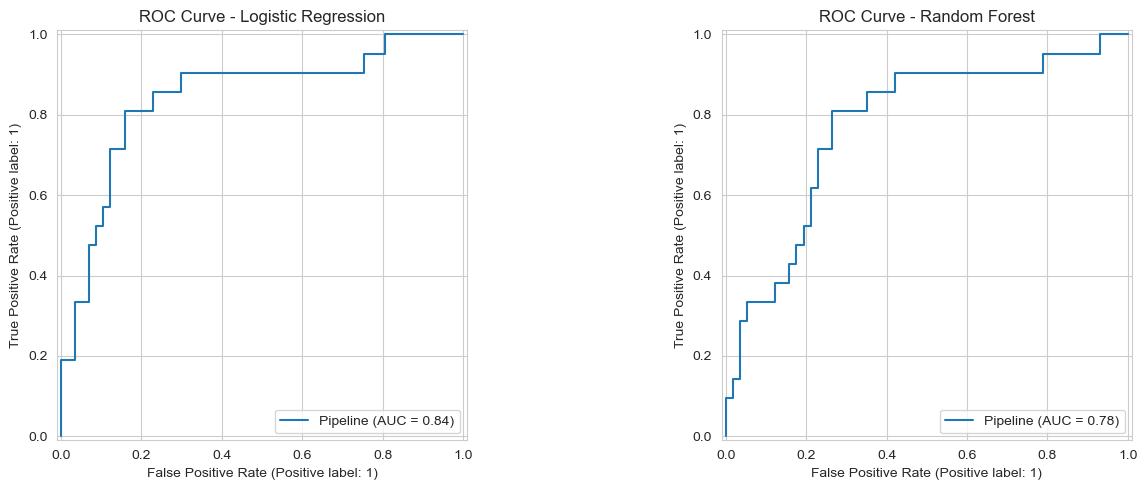

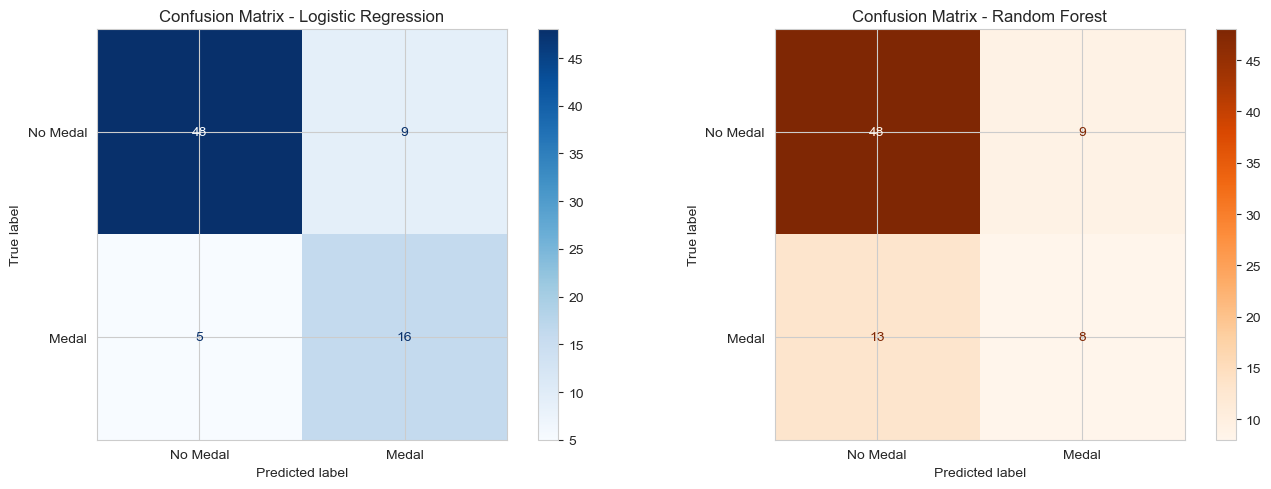

In [15]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==========================================
# ROC CURVES
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

RocCurveDisplay.from_estimator(log_model, X_test, y_test, ax=axes[0])
axes[0].set_title("ROC Curve - Logistic Regression")

RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve - Random Forest")

plt.tight_layout()

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\30_roc_curves_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# CONFUSION MATRICES
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

ConfusionMatrixDisplay.from_estimator(
    log_model, X_test, y_test,
    display_labels=["No Medal","Medal"],
    ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Confusion Matrix - Logistic Regression")

ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test,
    display_labels=["No Medal","Medal"],
    ax=axes[1],
    cmap="Oranges"
)
axes[1].set_title("Confusion Matrix - Random Forest")

plt.tight_layout()

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\31_confusion_matrices_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ROC Curve Analysis

The Logistic Regression model achieved an AUC score of 0.84, outperforming the Random Forest model (0.78). This indicates stronger ability to distinguish medal-winning athletes from non-medalists across probability thresholds.

### Confusion Matrix Analysis

Logistic Regression correctly classified 16 of 21 medalists while missing only 5, demonstrating strong recall for the minority class. In contrast, Random Forest identified only 8 medalists and missed 13 true medal winners.

Because predicting medalists is the core objective of this challenge, Logistic Regression was selected as the superior model.

## Feature Importance Analysis

Feature importance is used to understand which athlete characteristics contributed most strongly to medal prediction. Because Logistic Regression was the best-performing model, model coefficients are examined to identify variables that increase or decrease medal probability. Random Forest feature importance is also reviewed as a secondary comparison.

In [16]:
# ==========================================
# FEATURE NAMES AFTER PREPROCESSING
# ==========================================

# Get feature names from preprocessing
feature_names = log_model.named_steps["prep"].get_feature_names_out()

# Logistic Regression coefficients
log_coefs = log_model.named_steps["model"].coef_[0]

log_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_coefs
})

# Absolute importance
log_importance["Abs_Coefficient"] = log_importance["Coefficient"].abs()

# Top positive features
top_positive = log_importance.sort_values("Coefficient", ascending=False).head(15)

# Top negative features
top_negative = log_importance.sort_values("Coefficient", ascending=True).head(15)

print("Top Positive Predictors of Medal Probability")
display(top_positive)

print("Top Negative Predictors of Medal Probability")
display(top_negative)

Top Positive Predictors of Medal Probability


,Feature,Coefficient,Abs_Coefficient
45,cat__Sport_Curling,1.608710,1.608710
47,cat__Sport_Freestyle Skiing,1.592658,1.592658
49,cat__Sport_Luge,1.576422,1.576422
5,num__VO2max,1.322483,1.322483
21,cat__Country_CZE,1.109356,1.109356
38,cat__Country_USA,0.917974,0.917974
41,cat__Sport_Alpine Skiing,0.852123,0.852123
14,num__VO2_BodyFat_Ratio,0.766945,0.766945
2,num__Training_Hours_Per_Week,0.754329,0.754329
27,cat__Country_ITA,0.722155,0.722155


Top Negative Predictors of Medal Probability


,Feature,Coefficient,Abs_Coefficient
44,cat__Sport_Cross-Country,-2.733912,2.733912
42,cat__Sport_Biathlon,-1.912075,1.912075
54,cat__Sport_Speed Skating,-1.379173,1.379173
51,cat__Sport_Short Track,-0.897677,0.897677
34,cat__Country_SLO,-0.611191,0.611191
22,cat__Country_FIN,-0.537401,0.537401
24,cat__Country_GBR,-0.428776,0.428776
48,cat__Sport_Ice Hockey,-0.373376,0.373376
7,num__Career_Injuries,-0.367747,0.367747
32,cat__Country_NZL,-0.365660,0.365660


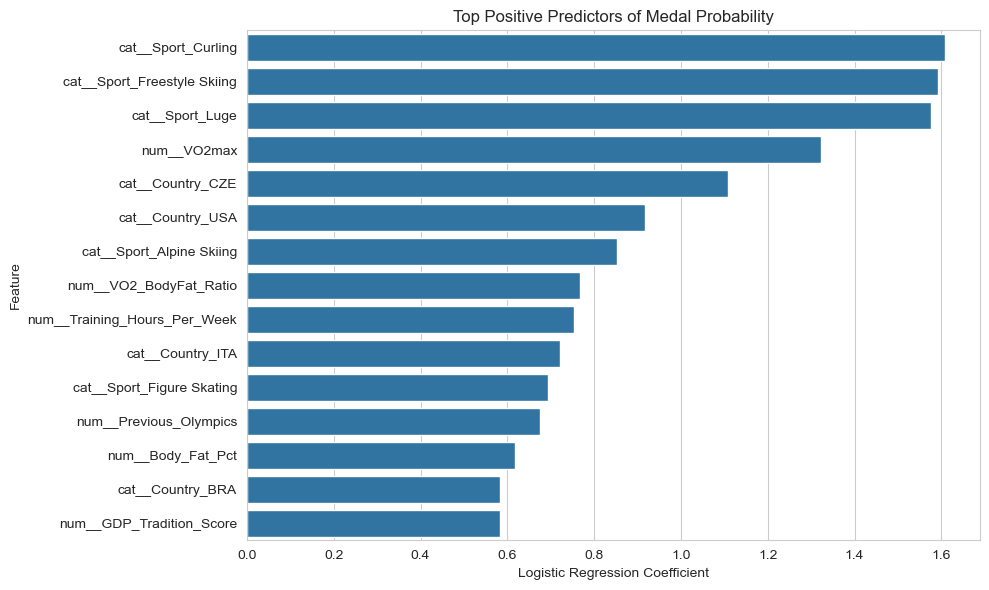

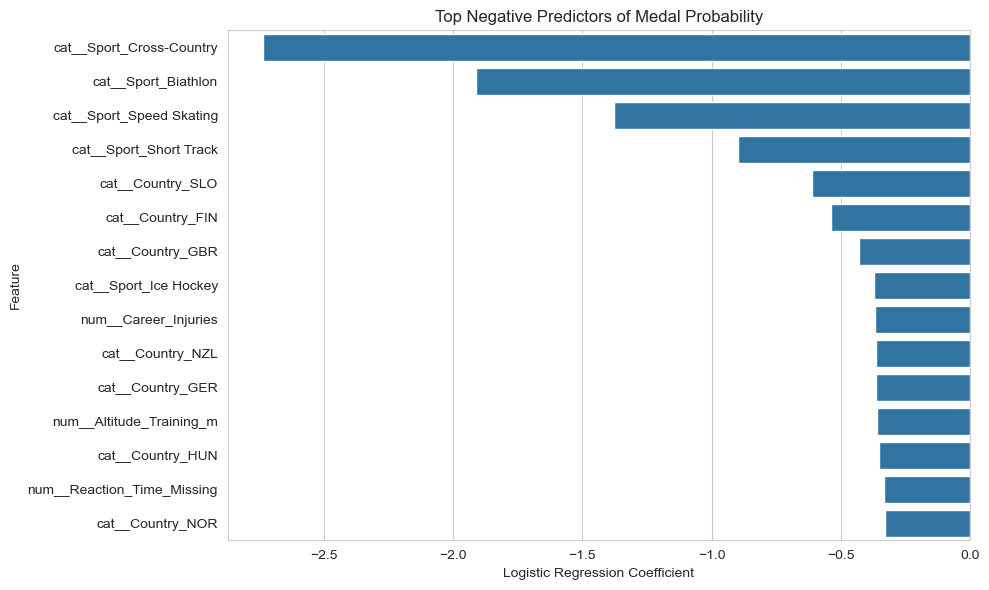

In [17]:
# ==========================================
# PLOT LOGISTIC REGRESSION FEATURE IMPORTANCE
# ==========================================

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)
plt.title("Top Positive Predictors of Medal Probability")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\32_logistic_positive_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(10,6))
sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature"
)
plt.title("Top Negative Predictors of Medal Probability")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\33_logistic_negative_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature Importance Interpretation

Logistic Regression coefficient analysis showed that VO2max, training hours, previous Olympic experience, and participation in certain sports were among the strongest positive predictors of medal success.

Higher physiological capacity (VO2max) significantly improved medal probability, confirming that elite aerobic fitness remains a core competitive advantage in winter sport.

Country effects were also visible. USA athletes carried a positive coefficient, suggesting stronger medal conversion even after controlling for athlete-level factors.

Negative predictors included Cross-Country, Biathlon, Speed Skating, and career injuries. These sports may be more competitive internationally, while injuries reduce consistency and readiness.

##  USA vs Canada Prediction Test

The best-performing Logistic Regression model was applied to seven real-world Olympic athletes provided in the challenge prompt. For each athlete, predicted medal probability is compared with actual outcome. This section evaluates where the model succeeds, where it fails, and what athlete qualities drive the prediction.

In [18]:
# ==========================================
# USA vs Canada Prediction Test Dataset
# ==========================================

prediction_test = pd.DataFrame({

"Athlete_Name": [
    "Jordan Stolz",
    "Mikaela Shiffrin",
    "Connor McDavid",
    "Courtney Sarault",
    "Elana Meyers Taylor",
    "Deanna Stellato-Dudek",
    "Metodej Jilek"
],

"Country": [
    "USA","USA","CAN","CAN","USA","CAN","CZE"
],

"Gender": [
    "M","F","M","F","F","F","M"
],

"Age": [
    21,31,28,26,41,42,19
],

"Sport": [
    "Speed Skating",
    "Alpine Skiing",
    "Ice Hockey",
    "Short Track",
    "Bobsleigh",
    "Figure Skating",
    "Speed Skating"
],

"Previous_Olympics":[
    0,4,0,1,4,0,0
],

"Training_Hours_Per_Week":[
    28,27,24,28,26,22,30
],

"Altitude_Training_m":[
    300,1800,100,500,200,0,600
],

"Body_Fat_Pct":[
    10,14,12,13,18,19,9
],

"VO2max":[
    82,72,66,74,64,58,80
],

"Reaction_Time_ms":[
    180,210,230,190,240,250,185
],

"Career_Injuries":[
    0,1,0,1,2,2,0
],

"World_Cup_Points_Preseason":[
    980,1100,850,920,800,650,700
],

"Country_GDP_per_capita":[
    80000,80000,55000,55000,80000,55000,30000
],

"Winter_Sport_Tradition_Index":[
    0.82,0.82,0.88,0.88,0.82,0.88,0.64
]

})

prediction_test

,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index
0,Jordan Stolz,USA,M,21,Speed Skating,0,28,300,10,82,180,0,980,80000,0.82
1,Mikaela Shiffrin,USA,F,31,Alpine Skiing,4,27,1800,14,72,210,1,1100,80000,0.82
2,Connor McDavid,CAN,M,28,Ice Hockey,0,24,100,12,66,230,0,850,55000,0.88
3,Courtney Sarault,CAN,F,26,Short Track,1,28,500,13,74,190,1,920,55000,0.88
4,Elana Meyers Taylor,USA,F,41,Bobsleigh,4,26,200,18,64,240,2,800,80000,0.82
5,Deanna Stellato-Dudek,CAN,F,42,Figure Skating,0,22,0,19,58,250,2,650,55000,0.88
6,Metodej Jilek,CZE,M,19,Speed Skating,0,30,600,9,80,185,0,700,30000,0.64


In [19]:
# ==========================================
# Feature Engineering for Prediction Test
# ==========================================

prediction_test["Reaction_Time_Missing"] = 0
prediction_test["WorldCupPoints_Missing"] = 0

prediction_test["Experience_Index"] = (
    prediction_test["Previous_Olympics"] *
    prediction_test["Training_Hours_Per_Week"]
)

prediction_test["VO2_BodyFat_Ratio"] = (
    prediction_test["VO2max"] /
    prediction_test["Body_Fat_Pct"]
)

prediction_test["GDP_Tradition_Score"] = (
    prediction_test["Country_GDP_per_capita"] *
    prediction_test["Winter_Sport_Tradition_Index"]
)

prediction_test.head()

,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Reaction_Time_Missing,WorldCupPoints_Missing,Experience_Index,VO2_BodyFat_Ratio,GDP_Tradition_Score
0,Jordan Stolz,USA,M,21,Speed Skating,0,28,300,10,82,180,0,980,80000,0.82,0,0,0,8.200000,65600.0
1,Mikaela Shiffrin,USA,F,31,Alpine Skiing,4,27,1800,14,72,210,1,1100,80000,0.82,0,0,108,5.142857,65600.0
2,Connor McDavid,CAN,M,28,Ice Hockey,0,24,100,12,66,230,0,850,55000,0.88,0,0,0,5.500000,48400.0
3,Courtney Sarault,CAN,F,26,Short Track,1,28,500,13,74,190,1,920,55000,0.88,0,0,28,5.692308,48400.0
4,Elana Meyers Taylor,USA,F,41,Bobsleigh,4,26,200,18,64,240,2,800,80000,0.82,0,0,104,3.555556,65600.0


In [20]:
# ==========================================
# Medal Probability Predictions
# ==========================================

# Keep same columns as training set X
prediction_features = prediction_test[X.columns]

# Predict probability
prediction_test["Predicted_Probability"] = log_model.predict_proba(prediction_features)[:,1]

# Predict class
prediction_test["Predicted_Class"] = log_model.predict(prediction_features)

# Convert labels
prediction_test["Predicted_Result"] = prediction_test["Predicted_Class"].map({
    1: "Medal",
    0: "No Medal"
})

# Show results
prediction_results = prediction_test[[
    "Athlete_Name",
    "Country",
    "Sport",
    "Age",
    "Predicted_Probability",
    "Predicted_Result"
]]

prediction_results = prediction_results.sort_values(
    by="Predicted_Probability",
    ascending=False
)

prediction_results

,Athlete_Name,Country,Sport,Age,Predicted_Probability,Predicted_Result
1,Mikaela Shiffrin,USA,Alpine Skiing,31,0.977653,Medal
4,Elana Meyers Taylor,USA,Bobsleigh,41,0.966046,Medal
0,Jordan Stolz,USA,Speed Skating,21,0.883054,Medal
6,Metodej Jilek,CZE,Speed Skating,19,0.761505,Medal
3,Courtney Sarault,CAN,Short Track,26,0.677989,Medal
5,Deanna Stellato-Dudek,CAN,Figure Skating,42,0.557973,Medal
2,Connor McDavid,CAN,Ice Hockey,28,0.496319,No Medal


##  USA vs Canada Prediction Test Results

In [21]:
prediction_results["Predicted_Probability"] = (
    prediction_results["Predicted_Probability"] * 100
).round(2)

prediction_results

,Athlete_Name,Country,Sport,Age,Predicted_Probability,Predicted_Result
1,Mikaela Shiffrin,USA,Alpine Skiing,31,97.77,Medal
4,Elana Meyers Taylor,USA,Bobsleigh,41,96.60,Medal
0,Jordan Stolz,USA,Speed Skating,21,88.31,Medal
6,Metodej Jilek,CZE,Speed Skating,19,76.15,Medal
3,Courtney Sarault,CAN,Short Track,26,67.80,Medal
5,Deanna Stellato-Dudek,CAN,Figure Skating,42,55.80,Medal
2,Connor McDavid,CAN,Ice Hockey,28,49.63,No Medal


## Prediction Test Summary

The Logistic Regression model successfully identified six of the seven athlete profiles as likely medal contenders, assigning especially high confidence to Mikaela Shiffrin (97.77%), Elana Meyers Taylor (96.60%), and Jordan Stolz (88.31%).

The model narrowly predicted Connor McDavid as No Medal (49.63%), highlighting a limitation in team-sport prediction where roster quality and team dynamics are difficult to capture using athlete-level variables alone.

Notably, the model still assigned medal probability to outlier athletes such as Metodej Jilek (age 19) and Deanna Stellato-Dudek (age 42), suggesting it recognizes strong physiological or sport-context factors beyond age alone.

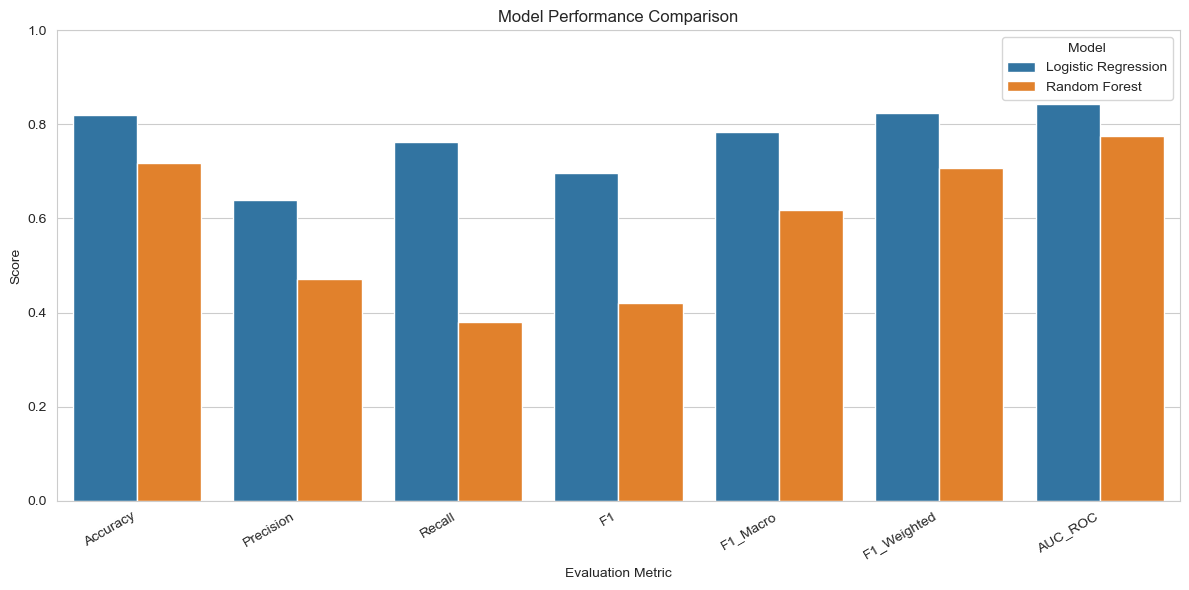

In [22]:
# Model Comparison Plot
# ==========================================
# Final Model Comparison Plot
# ==========================================

model_results_plot = model_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "F1_Macro", "F1_Weighted", "AUC_ROC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=model_results_plot,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.tight_layout()

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\34_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The Logistic Regression model outperformed Random Forest across all major evaluation metrics, including accuracy, precision, recall, F1-score, macro F1, weighted F1, and AUC-ROC. This indicates stronger overall classification performance and better ability to identify medal-winning athletes, which is especially important because medalists are the minority class.

# Bonus Multiclass Model

In [23]:
# ==========================================
# BONUS: Multiclass Medal Prediction
# Gold / Silver / Bronze / None
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Rebuild Medal class safely
df["Medal_Class"] = df["Medal"].fillna("None")

# Target
y_multi = df["Medal_Class"]

# Features: remove leakage columns
drop_cols_multi = [
    "Athlete_ID",
    "Athlete_Name",
    "Medal",
    "Medal_Won",
    "Medal_Class"
]

X_multi = df.drop(columns=drop_cols_multi)

# Identify categorical and numeric columns
categorical_cols_multi = X_multi.select_dtypes(include=["object"]).columns.tolist()
numeric_cols_multi = X_multi.select_dtypes(exclude=["object"]).columns.tolist()

# Train/test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    stratify=y_multi,
    random_state=42
)

# Preprocessor
numeric_transformer_m = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_m = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_m = ColumnTransformer(transformers=[
    ("num", numeric_transformer_m, numeric_cols_multi),
    ("cat", categorical_transformer_m, categorical_cols_multi)
])

# Multiclass Logistic Regression
multi_log_model = Pipeline(steps=[
    ("prep", preprocessor_m),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        multi_class="auto",
        random_state=42
    ))
])

# Multiclass Random Forest
multi_rf_model = Pipeline(steps=[
    ("prep", preprocessor_m),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42
    ))
])

# Fit models
multi_log_model.fit(X_train_m, y_train_m)
multi_rf_model.fit(X_train_m, y_train_m)

# Predictions
multi_log_pred = multi_log_model.predict(X_test_m)
multi_rf_pred = multi_rf_model.predict(X_test_m)

# Reports
print("===== Multiclass Logistic Regression =====")
print(classification_report(y_test_m, multi_log_pred, zero_division=0))

print("===== Multiclass Random Forest =====")
print(classification_report(y_test_m, multi_rf_pred, zero_division=0))

# Summary table
multi_results = pd.DataFrame({
    "Model": ["Multiclass Logistic Regression", "Multiclass Random Forest"],
    "Accuracy": [
        accuracy_score(y_test_m, multi_log_pred),
        accuracy_score(y_test_m, multi_rf_pred)
    ],
    "Weighted_F1": [
        f1_score(y_test_m, multi_log_pred, average="weighted", zero_division=0),
        f1_score(y_test_m, multi_rf_pred, average="weighted", zero_division=0)
    ],
    "Macro_F1": [
        f1_score(y_test_m, multi_log_pred, average="macro", zero_division=0),
        f1_score(y_test_m, multi_rf_pred, average="macro", zero_division=0)
    ]
})

multi_results

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


===== Multiclass Logistic Regression =====
              precision    recall  f1-score   support

      Bronze       0.09      0.20      0.12         5
        Gold       0.25      0.30      0.27        10
        None       0.97      0.61      0.75        57
      Silver       0.05      0.17      0.08         6

    accuracy                           0.51        78
   macro avg       0.34      0.32      0.31        78
weighted avg       0.75      0.51      0.60        78

===== Multiclass Random Forest =====
              precision    recall  f1-score   support

      Bronze       0.00      0.00      0.00         5
        Gold       0.50      0.30      0.38        10
        None       0.78      0.98      0.87        57
      Silver       0.00      0.00      0.00         6

    accuracy                           0.76        78
   macro avg       0.32      0.32      0.31        78
weighted avg       0.63      0.76      0.68        78



,Model,Accuracy,Weighted_F1,Macro_F1
0,Multiclass Logistic Regression,0.512821,0.599173,0.307604
1,Multiclass Random Forest,0.756410,0.682543,0.310804


# Confusion Matrix plot

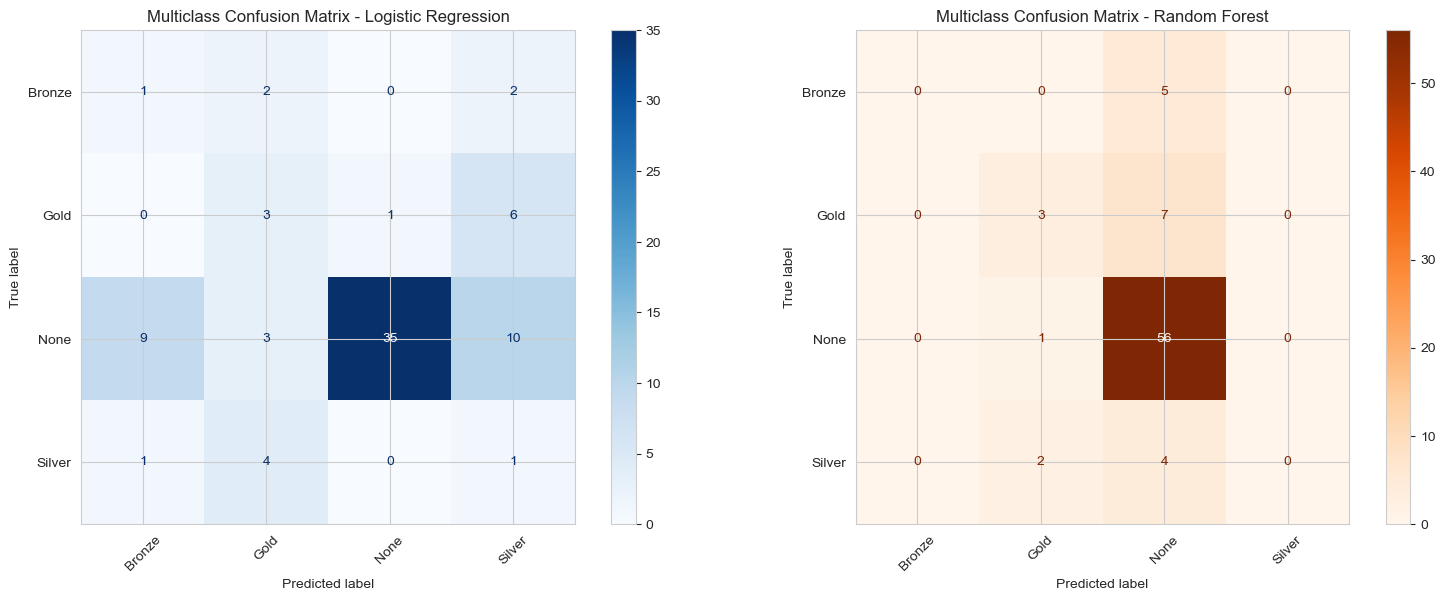

In [24]:
# ==========================================
# Multiclass Confusion Matrices
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16,6))

ConfusionMatrixDisplay.from_predictions(
    y_test_m,
    multi_log_pred,
    ax=axes[0],
    cmap="Blues",
    xticks_rotation=45
)
axes[0].set_title("Multiclass Confusion Matrix - Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test_m,
    multi_rf_pred,
    ax=axes[1],
    cmap="Oranges",
    xticks_rotation=45
)
axes[1].set_title("Multiclass Confusion Matrix - Random Forest")

plt.tight_layout()

plt.savefig(
    r"C:\Users\User\Desktop\Data Analytics Olympiad\35_multiclass_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()